## 1. Load the dataset


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

file_path = '/content/data_academic_performance.xlsx'
df = pd.read_excel(file_path, sheet_name='SABER11_SABERPRO')

print(df.shape)
df.head()


(12411, 45)


,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


Output: **(12411, 45)** in Excel layout; one column is blank in the source workbook and can be ignored. The substantive dataset contains 44 named variables.


## 2. Numerical summary


In [5]:
numeric_cols = [
    'MAT_S11','CR_S11','CC_S11','BIO_S11','ENG_S11',
    'QR_PRO','CR_PRO','CC_PRO','ENG_PRO','WC_PRO','FEP_PRO',
    'G_SC','PERCENTILE','2ND_DECILE','QUARTILE','SEL','SEL_IHE'
]

df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
MAT_S11,12411.0,64.320764,11.873650,26.0,56.0,64.0,72.0,100.0
CR_S11,12411.0,60.778422,10.025876,24.0,54.0,61.0,67.0,100.0
CC_S11,12411.0,60.705181,10.120524,0.0,54.0,60.0,67.0,100.0
BIO_S11,12411.0,63.950528,11.156869,11.0,56.0,64.0,71.0,100.0
ENG_S11,12411.0,61.801064,14.297777,26.0,50.0,59.0,72.0,100.0
QR_PRO,12411.0,77.417291,22.673444,1.0,65.0,85.0,96.0,100.0
CR_PRO,12411.0,62.199339,27.666558,1.0,42.0,67.0,86.0,100.0
CC_PRO,12411.0,59.186770,28.991840,1.0,36.0,65.0,85.0,100.0
ENG_PRO,12411.0,67.498348,25.495096,1.0,51.0,74.0,88.0,100.0
WC_PRO,12411.0,53.703408,30.001734,0.0,28.0,56.0,80.0,100.0


The overall mean global score (`G_SC`) is approximately **162.71**, with a standard deviation of approximately **23.11**.


## 3. Parental education and outcomes


In [6]:
# Remove categories that do not provide a usable education level
mother = df[~df['EDU_MOTHER'].isin(['0', 'Not sure'])].copy()
father = df[~df['EDU_FATHER'].isin(['0', 'Not sure'])].copy()

mother_summary = (mother.groupby('EDU_MOTHER')['G_SC']
                  .agg(['count','mean','std'])
                  .sort_values('mean', ascending=False))
father_summary = (father.groupby('EDU_FATHER')['G_SC']
                  .agg(['count','mean','std'])
                  .sort_values('mean', ascending=False))

display(mother_summary)
display(father_summary)


,count,mean,std
EDU_MOTHER,,,
Postgraduate education,997,175.636911,22.119758
Complete professional education,3059,168.845374,22.978321
Incomplete Professional Education,502,166.685259,22.931830
Complete technique or technology,1495,163.242140,21.943495
Incomplete technical or technological,341,161.879765,20.744388
Complete Secundary,3106,158.470702,21.949597
Incomplete Secundary,1056,155.672348,21.928635
Complete primary,713,155.336606,22.012293
0,388,154.930412,19.954154


,count,mean,std
EDU_FATHER,,,
Postgraduate education,1085,176.985253,21.734132
Complete professional education,3016,167.765915,23.030089
Incomplete Professional Education,425,166.917647,22.685198
Complete technique or technology,1194,164.033501,22.165359
Incomplete technical or technological,277,162.101083,21.881198
Complete Secundary,2843,158.785790,22.114288
Ninguno,123,156.634146,23.188560
Incomplete Secundary,1091,156.535289,21.736989
Incomplete primary,735,155.729252,20.942412


In [7]:
def one_way_eta_squared(data, group_col, outcome_col):
    groups = [g[outcome_col].dropna().values for _, g in data.groupby(group_col)]
    f_stat, p_value = stats.f_oneway(*groups)
    grand_mean = data[outcome_col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = ((data[outcome_col] - grand_mean)**2).sum()
    eta_sq = ss_between / ss_total
    return f_stat, p_value, eta_sq

print('Mother education:', one_way_eta_squared(mother, 'EDU_MOTHER', 'G_SC'))
print('Father education:', one_way_eta_squared(father, 'EDU_FATHER', 'G_SC'))


Mother education: (np.float64(101.60249229261204), np.float64(2.367503776100604e-203), np.float64(0.07675628993992402))
Father education: (np.float64(102.04449445579323), np.float64(4.4725732801043745e-204), np.float64(0.07841466643962476))


**Key result:** Maternal education explains about **7.5%** of the variation in `G_SC` in a one-way comparison (eta-squared ≈ 0.075), and paternal education explains about **7.7%** (eta-squared ≈ 0.077). Students whose mothers had postgraduate education averaged about **175.64**, compared with **158.47** for complete secondary education. Students whose fathers had postgraduate education averaged about **176.99**, compared with **158.79** for complete secondary education. These are associations and do not by themselves prove causation.


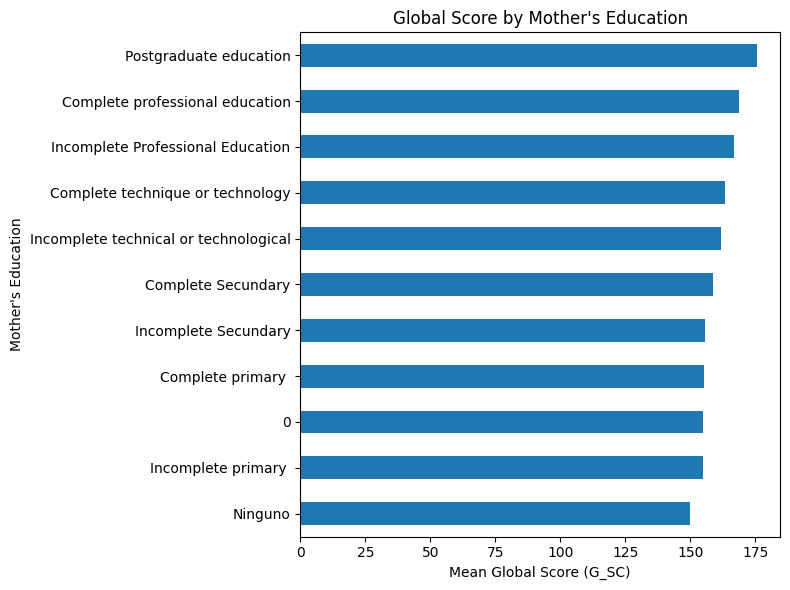

In [8]:
mother_summary['mean'].sort_values().plot(kind='barh', figsize=(8,6))
plt.xlabel('Mean Global Score (G_SC)')
plt.ylabel("Mother's Education")
plt.title("Global Score by Mother's Education")
plt.tight_layout()
plt.show()


## 4. Socioeconomic stratum


In [9]:
stratum = df[df['STRATUM'] != '0'].copy()

stratum_order = [f'Stratum {i}' for i in range(1,7)]
stratum_summary = (stratum.groupby('STRATUM')['G_SC']
                   .agg(['count','mean','std'])
                   .reindex(stratum_order))

display(stratum_summary)
print(one_way_eta_squared(stratum, 'STRATUM', 'G_SC'))


,count,mean,std
STRATUM,,,
Stratum 1,1709,152.352838,21.937401
Stratum 2,4029,158.199305,22.278029
Stratum 3,4045,163.815328,21.693970
Stratum 4,1578,172.002535,21.469094
Stratum 5,633,177.387046,21.543236
Stratum 6,403,181.511166,21.879401


(np.float64(238.76914026732305), np.float64(8.289596738433048e-290), np.float64(0.10353795765828142))


**Key result:** Mean global scores rise steadily with socioeconomic stratum. Stratum 1 averages about **152.35**, while Stratum 6 averages about **181.51**, a difference of approximately **29.16 points**. Stratum accounts for about **10.3%** of the observed variation in global scores in a one-way ANOVA (eta-squared ≈ 0.103).


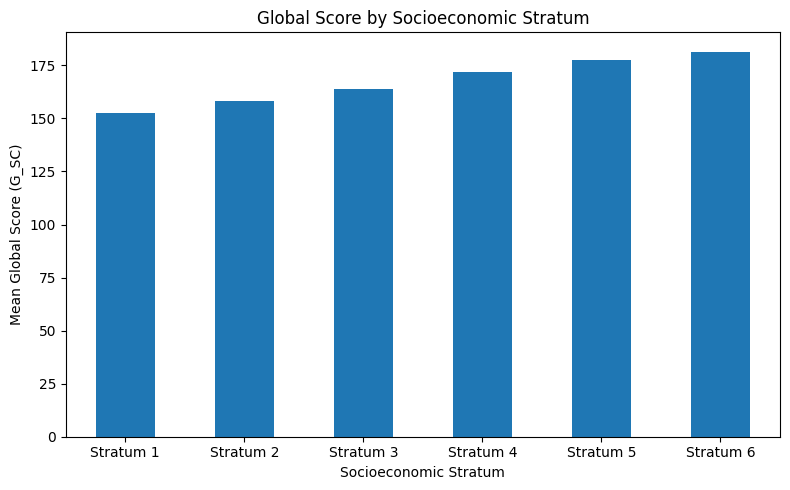

In [10]:
stratum_summary['mean'].plot(kind='bar', figsize=(8,5))
plt.ylabel('Mean Global Score (G_SC)')
plt.xlabel('Socioeconomic Stratum')
plt.title('Global Score by Socioeconomic Stratum')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Gender and global assessment


In [11]:
gender_summary = df.groupby('GENDER')['G_SC'].agg(['count','mean','std','median'])
display(gender_summary)

male = df.loc[df['GENDER']=='M', 'G_SC']
female = df.loc[df['GENDER']=='F', 'G_SC']
t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)

pooled_sd = np.sqrt(((len(male)-1)*male.var() + (len(female)-1)*female.var()) /
                    (len(male)+len(female)-2))
cohen_d = (male.mean() - female.mean()) / pooled_sd

print('Mean difference:', male.mean() - female.mean())
print('Welch t-test p-value:', p_value)
print("Cohen's d:", cohen_d)


,count,mean,std,median
GENDER,,,,
F,5043,161.278207,22.332939,162.0
M,7368,163.690825,23.582616,164.0


Mean difference: 2.4126177737903447
Welch t-test p-value: 7.785030938251425e-09
Cohen's d: 0.10451919678617907


**Key result:** Male students average about **163.69** on `G_SC`, while female students average about **161.28**. The difference is about **2.41 points**. It is statistically significant because of the large sample, but the standardized difference is small (**Cohen's d ≈ 0.105**).


In [12]:
pro_components = ['QR_PRO','CR_PRO','CC_PRO','ENG_PRO','WC_PRO','FEP_PRO','G_SC']
gender_components = df.groupby('GENDER')[pro_components].mean().T
display(gender_components)


GENDER,F,M
QR_PRO,71.892723,81.198561
CR_PRO,61.338687,62.788409
CC_PRO,58.573865,59.606270
ENG_PRO,66.532421,68.159473
WC_PRO,56.618084,51.708469
FEP_PRO,145.302796,145.595548
G_SC,161.278207,163.690825


An important detail is that the gender pattern differs by skill. Male students have a higher mean in Quantitative Reasoning (`QR_PRO`: about **81.20** versus **71.89**), while female students have a higher mean in Written Communication (`WC_PRO`: about **56.62** versus **51.71**). This suggests that the small global-score difference hides larger differences in specific skill areas.


## 6. Academic program comparison


In [13]:
program_summary = (df.groupby('ACADEMIC_PROGRAM')['G_SC']
                   .agg(['count','mean','std'])
                   .sort_values('mean', ascending=False))

# Use a minimum sample size to avoid ranking programs based on very small groups.
program_large = program_summary[program_summary['count'] >= 100]
display(program_large)


,count,mean,std
ACADEMIC_PROGRAM,,,
CHEMICAL ENGINEERING,1000,176.697000,18.690707
ELECTRIC ENGINEERING,278,173.989209,19.354285
ELECTRONIC ENGINEERING,849,166.872792,22.204832
MECHANICAL ENGINEERING,1135,166.051982,23.262628
CIVIL ENGINEERING,3320,161.110542,22.825922
INDUSTRIAL ENGINEERING,5318,159.042497,23.159611


Among programs with at least 100 students, **Chemical Engineering** has the highest average global score at about **176.70**, followed by **Electric Engineering** at about **173.99**. Electronic and Mechanical Engineering average about **166.87** and **166.05**, while Civil Engineering averages about **161.11** and Industrial Engineering about **159.04**. These differences should not be interpreted as direct measures of program quality because student selection, institution, socioeconomic background, and prior achievement may differ across programs.


## 7. Additional socioeconomic indicators


In [14]:
for col in ['SISBEN', 'REVENUE', 'SCHOOL_NAT', 'INTERNET', 'COMPUTER', 'SEL_IHE']:
    print('\n', col)
    display(df.groupby(col)['G_SC'].agg(['count','mean','std']).sort_values('mean', ascending=False))



 SISBEN


,count,mean,std
SISBEN,,,
It is not classified by the SISBEN,7534,167.469074,22.478021
Esta clasificada en otro Level del SISBEN,96,166.052083,22.511457
Level 3,583,160.991424,21.640175
0,21,158.619048,20.086006
Level 2,2120,155.893396,22.268725
Level 1,2057,152.680603,21.657454



 REVENUE


,count,mean,std
REVENUE,,,
10 or more LMMW,718,183.672702,20.722113
Between 7 and less than 10 LMMW,509,176.176817,19.964343
Between 5 and less than 7 LMMW,973,170.860226,21.786822
0,279,169.716846,22.637003
Between 3 and less than 5 LMMW,2239,165.336311,22.075666
Between 2 and less than 3 LMMW,2783,160.942867,21.633473
Between 1 and less than 2 LMMW,3873,156.770462,22.045776
less than 1 LMMW,1037,153.314368,22.014683



 SCHOOL_NAT


...

,count,mean,std
INTERNET,,,
Yes,9752,164.917453,22.862456
No,2659,154.616397,22.206930



 COMPUTER


,count,mean,std
COMPUTER,,,
Yes,10174,164.196383,23.116346
No,2237,155.952615,21.860398



 SEL_IHE


,count,mean,std
SEL_IHE,,,
4,2692,178.848068,20.176358
3,834,164.816547,17.212915
2,7748,158.281363,22.274716
1,1137,153.139842,20.605208


Several other variables show meaningful gaps. Students with internet access average about **164.92**, versus **154.62** without internet. Students from private high schools average about **168.22**, versus **156.53** from public high schools. Household revenue also has a strong gradient. These patterns support an equity-focused interpretation, but they are descriptive associations rather than causal estimates.
